In [1]:
import warnings
import pickle
from tqdm import tqdm
import numpy as np
from optiland import optic, materials, optimization

In [2]:
with open('kde_model.pkl', 'rb') as f:
    kde = pickle.load(f)

In [3]:
class Doublet(optic.Optic):

    def __init__(self, kde=kde):
        super().__init__()

        r0 = np.random.uniform(10, 500) * np.random.choice([-1, 1])
        r1 = np.random.uniform(10, 500) * np.random.choice([-1, 1])
        r2 = np.random.uniform(10, 500) * np.random.choice([-1, 1])

        t0 = np.random.uniform(0.1, 10)
        t1 = np.random.uniform(0.1, 10)
        t2 = np.random.uniform(5.0, 200.0)

        n0, v0 = kde.resample(1).ravel()
        n1, v1 = kde.resample(1).ravel()

        f_number = np.random.uniform(1.0, 10.0)

        self.properties = [r0, r1, r2, t0, t1, t2, n0, v0, n1, v1, f_number]

        mat0 = materials.AbbeMaterial(n=n0, abbe=v0)
        mat1 = materials.AbbeMaterial(n=n1, abbe=v1)

        # add surfaces
        self.add_surface(index=0, radius=np.inf, thickness=np.inf)
        self.add_surface(index=1, thickness=t0, radius=r0, is_stop=True, material=mat0)
        self.add_surface(index=2, thickness=t1, radius=r1, material=mat1)
        self.add_surface(index=3, thickness=t2, radius=r2)
        self.add_surface(index=4)

        # add aperture
        self.set_aperture(aperture_type='imageFNO', value=f_number)

        # add field
        self.set_field_type(field_type='angle')
        self.add_field(y=0.0)

        # add wavelength
        self.add_wavelength(value=0.55, is_primary=True)

    def scale_to_unity_focal_length(self):
        """Scale the system to unity focal length"""
        f = self.paraxial.f2()
        self.scale_system(1/f)

    def optimize(self):
        """Optimize the system"""
        problem = optimization.OptimizationProblem()

        input_data = {'optic': self, 'surface_number': -1, 'Hx': 0, 'Hy': 0,
                      'num_rays': 5, 'wavelength': 0.55, 'distribution': 'hexapolar'}

        # add RMS spot size operand
        problem.add_operand(operand_type='rms_spot_size', target=0, weight=1, input_data=input_data)
        problem.add_operand(operand_type='f2', target=1, weight=0, input_data={'optic': self})

        problem.add_variable(self, 'radius', surface_number=1)
        problem.add_variable(self, 'radius', surface_number=2)
        problem.add_variable(self, 'radius', surface_number=3)
        problem.add_variable(self, 'thickness', surface_number=1, min_val=0.1, max_val=10)
        problem.add_variable(self, 'thickness', surface_number=2, min_val=0.1, max_val=10)
        problem.add_variable(self, 'thickness', surface_number=3, min_val=0, max_val=None)

        optimizer = optimization.OptimizerGeneric(problem)
        res = optimizer.optimize(tol=1e-3, maxiter=100)

        # udpate lens properties - inverse scale to put in original units
        self.properties[:6] = [var.variable.inverse_scale(var.value) for var in problem.variables]

        self.properties += [problem.operands[0].value]  # append final spot size to properties

        return res

In [4]:
target_num_samples = 1000

pbar = tqdm(total=target_num_samples)

data = []
while len(data) < target_num_samples:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        lens = Doublet()
        lens.scale_to_unity_focal_length()
        res = lens.optimize()
        p = lens.properties

    if not np.any(np.isnan(p)):
        data.append(p)
        pbar.update(1)

100%|██████████| 1000/1000 [08:03<00:00,  3.40it/s]

In [5]:
lens.info()  # print last lens summary

╒════╤═════════════════╤═══════════╤════════════╤═════════════╤═══════════════╤═════════╤═════════════════╕
│    │ Type            │ Comment   │     Radius │   Thickness │ Material      │   Conic │   Semi-aperture │
╞════╪═════════════════╪═══════════╪════════════╪═════════════╪═══════════════╪═════════╪═════════════════╡
│  0 │ Planar          │           │ inf        │  inf        │ Air           │       0 │      0.0689901  │
│  1 │ Stop - Standard │           │   2.42453  │    0.1      │ 1.5143, 56.41 │       0 │      0.0689901  │
│  2 │ Standard        │           │  -0.305558 │    0.1      │ 1.6534, 56.66 │       0 │      0.0680215  │
│  3 │ Standard        │           │  -0.267681 │    0.435217 │ Air           │       0 │      0.0690125  │
│  4 │ Planar          │           │ inf        │  nan        │ Air           │       0 │      0.00257599 │
╘════╧═════════════════╧═══════════╧════════════╧═════════════╧═══════════════╧═════════╧═════════════════╛



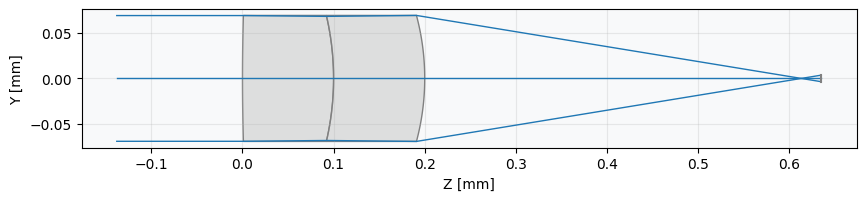

In [6]:
_ = lens.draw()

In [7]:
array_data = np.array(data)

In [8]:
np.save('doublet_data.npy', array_data)